<a href="https://colab.research.google.com/github/matthargrove/DATA543-Final-Project/blob/main/DATA543_Project_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Loading and Preprocessing
Combines EIA datasets and cleans duplicate project entries.

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os # Import os for path manipulation

# --- USER CONFIGURATION: Update this path to where your CSV files are located ---
# Example for files directly in Colab's content folder: base_directory = '/content/'
# Example for files in Google Drive: base_directory = '/content/drive/MyDrive/Your_Folder_Name/'
base_directory = '/content/' # Default: assuming files are directly in /content/

# List of all generator CSV files (filenames only)
csv_filenames = [
    'december_generator2025_OP.csv',
    'december_generator2023_OP.csv',
    'december_generator2024_OP.csv',
    'december_generator2022_PLANNED.csv',
    'december_generator2025_PLANNED.csv',
    'december_generator2024_PLANNED.csv',
    'december_generator2022_OP.csv',
    'december_generator2023_PLANNED.csv'
]

# Construct full paths using the base_directory
csv_files = [os.path.join(base_directory, filename) for filename in csv_filenames]

all_generators_df = pd.DataFrame()

for file_path in csv_files:
    try:
        df_temp = pd.read_csv(file_path)
        # Add a column to distinguish between operating and planned files
        if '_OP.csv' in file_path:
            df_temp['File_Type'] = 'Operating'
        elif '_PLANNED.csv' in file_path:
            df_temp['File_Type'] = 'Planned'
        all_generators_df = pd.concat([all_generators_df, df_temp], ignore_index=True)
    except FileNotFoundError:
        print(f"Warning: File not found at {file_path}. Skipping this file.")

# Drop duplicate entries based on Entity ID and Plant ID to avoid double-counting
# Assuming Entity ID and Plant ID uniquely identify a generator unit
# Only attempt to drop duplicates if the DataFrame is not empty and has the required columns
if not all_generators_df.empty and all(col in all_generators_df.columns for col in ['Entity ID', 'Plant ID', 'Operating Year']):
    all_generators_df.drop_duplicates(subset=['Entity ID', 'Plant ID', 'Operating Year'], inplace=True)


print("Combined DataFrame Info:")
display(all_generators_df.info())
display(all_generators_df.head())

Combined DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 39467 entries, 0 to 112170
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity ID                 39466 non-null  object 
 1   Plant ID                  39463 non-null  float64
 2   Sector                    39463 non-null  object 
 3   Nameplate Capacity (MW)   39463 non-null  object 
 4   Net Summer Capacity (MW)  39463 non-null  object 
 5   Net Winter Capacity (MW)  39463 non-null  object 
 6   Technology                39463 non-null  object 
 7   Operating Month           36452 non-null  float64
 8   Operating Year            36452 non-null  float64
 9   Planned Retirement Month  36452 non-null  object 
 10  Planned Retirement Year   36452 non-null  object 
 11  Status                    39463 non-null  object 
 12  Latitude                  39463 non-null  object 
 13  Longitude                 39463 non-null

None

,Entity ID,Plant ID,Sector,Nameplate Capacity (MW),Net Summer Capacity (MW),Net Winter Capacity (MW),Technology,Operating Month,Operating Year,Planned Retirement Month,Planned Retirement Year,Status,Latitude,Longitude,File_Type,Planned Operation Month,Planned Operation Year
0,63560,1.0,Electric Utility,0.9,0.4,0.4,Petroleum Liquids,12.0,2000.0,,,SB,55.339722,-160.4972,Operating,NaN,NaN
2,63560,1.0,Electric Utility,0.5,0.3,0.3,Petroleum Liquids,12.0,2010.0,,,OP,55.339722,-160.4972,Operating,NaN,NaN
3,63560,1.0,Electric Utility,0.4,0.3,0.3,Petroleum Liquids,2.0,2023.0,,,OP,55.339722,-160.4972,Operating,NaN,NaN
4,63560,1.0,Electric Utility,0.5,0.1,0.1,Onshore Wind Turbine,10.0,2011.0,,,OS,55.339722,-160.4972,Operating,NaN,NaN
6,195,2.0,Electric Utility,53.9,53,53,Conventional Hydroelectric,7.0,1963.0,,,OP,33.458665,-87.35682,Operating,NaN,NaN


### Technology and Year Filtering
Filters for Solar and Wind projects within the 2023-2025 target window.

In [58]:
# Define target technologies and years
clean_techs = ['Solar Photovoltaic', 'Onshore Wind Turbine', 'Offshore Wind Turbine']
TARGET_YEARS = [2023, 2024, 2025]

# Ensure Year and Month are numeric and Plant ID is a clean string
all_generators_df['Planned Operation Year'] = pd.to_numeric(all_generators_df['Planned Operation Year'], errors='coerce')
all_generators_df['Operating Year'] = pd.to_numeric(all_generators_df['Operating Year'], errors='coerce')
all_generators_df['Plant ID'] = all_generators_df['Plant ID'].astype(str).str.strip()

# Filter datasets into separate operational and planned dataframes
planned_df = all_generators_df[
    (all_generators_df['File_Type'] == 'Planned') &
    (all_generators_df['Technology'].isin(clean_techs)) &
    (all_generators_df['Planned Operation Year'].isin(TARGET_YEARS))
].copy()

operating_df = all_generators_df[
    (all_generators_df['File_Type'] == 'Operating') &
    (all_generators_df['Technology'].isin(clean_techs)) &
    (all_generators_df['Operating Year'].isin(TARGET_YEARS))
].copy()

### Project Matching and Delay Calculation
Merges planned and actual data to calculate construction delay in months.

In [59]:
import pandas as pd
import numpy as np

# Match projects by Plant ID and Technology to calculate actual delays
# We'll calculate delay_months = (Actual Date - Planned Date)

# Prepare dates for planned projects
planned_df['Planned Date'] = pd.to_datetime(
    planned_df['Planned Operation Year'].astype(int).astype(str) + '-' +
    planned_df['Planned Operation Month'].fillna(1).astype(int).astype(str).str.zfill(2) + '-01',
    errors='coerce'
)

# Prepare dates for operating projects
operating_df['Actual Date'] = pd.to_datetime(
    operating_df['Operating Year'].astype(int).astype(str) + '-' +
    operating_df['Operating Month'].fillna(1).astype(int).astype(str).str.zfill(2) + '-01',
    errors='coerce'
)

# Merge to find projects that transitioned from Planned to Operating
ml_ready_df = pd.merge(
    planned_df[['Plant ID', 'Technology', 'Nameplate Capacity (MW)', 'Latitude', 'Longitude', 'Planned Date']],
    operating_df[['Plant ID', 'Technology', 'Actual Date']],
    on=['Plant ID', 'Technology'],
    how='inner'
)

# Calculate delay in months
ml_ready_df['delay_months'] = (ml_ready_df['Actual Date'] - ml_ready_df['Planned Date']).dt.days / 30.44

print(f"Projects matched for ML: {len(ml_ready_df)}")
display(ml_ready_df.head())

Projects matched for ML: 1429


,Plant ID,Technology,Nameplate Capacity (MW),Latitude,Longitude,Planned Date,Actual Date,delay_months
0,60596.0,Onshore Wind Turbine,130.0,42.375,-77.593,2023-01-01,2023-02-01,1.018397
1,60596.0,Onshore Wind Turbine,130.0,42.375,-77.593,2023-01-01,2023-02-01,1.018397
2,63808.0,Solar Photovoltaic,75.0,33.899338,-81.40047,2023-01-01,2023-01-01,0.000000
3,63808.0,Solar Photovoltaic,75.0,33.899338,-81.40047,2023-01-01,2023-01-01,0.000000
4,63909.0,Solar Photovoltaic,60.0,36.807131,-78.50977,2023-01-01,2023-10-01,8.968463


### Delay Prediction Model (Ridge Regression)
Trains a machine learning pipeline to predict construction delays.

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Ensure all numeric features are actually numeric and handle empty strings
for col in ['Latitude', 'Longitude', 'Nameplate Capacity (MW)', 'delay_months']:
    ml_ready_df[col] = pd.to_numeric(ml_ready_df[col], errors='coerce')

# Filter out invalid records (NaNs created by coerce)
model_df = ml_ready_df.dropna(subset=['delay_months', 'Latitude', 'Longitude', 'Nameplate Capacity (MW)'])

# Features and Target
X = model_df[['Technology', 'Latitude', 'Longitude', 'Nameplate Capacity (MW)']]
y = model_df['delay_months']

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Latitude', 'Longitude', 'Nameplate Capacity (MW)']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Technology'])
    ])

# Define Ridge Regression model
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
ridge_pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred = ridge_pipeline.predict(X_test)
print(f"Ridge Regression R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")

Ridge Regression R2 Score: 0.0468
Mean Squared Error: 29.9271


### Capacity Prediction Model
Predicts project Nameplate Capacity (MW) based on location and year.

In [61]:
# Features for Capacity prediction
X_cap = model_df[['Technology', 'Latitude', 'Longitude', 'Planned Date']]
# Convert Planned Date to ordinal for numeric processing
X_cap['Planned_Year'] = X_cap['Planned Date'].dt.year
X_cap = X_cap.drop(columns=['Planned Date'])
y_cap = model_df['Nameplate Capacity (MW)']

# Update preprocessor for Year feature
preprocessor_cap = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Latitude', 'Longitude', 'Planned_Year']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Technology'])
    ])

cap_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_cap),
    ('regressor', Ridge(alpha=1.0))
])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cap, y_cap, test_size=0.2, random_state=42)
cap_pipeline.fit(X_train_c, y_train_c)

cap_pred = cap_pipeline.predict(X_test_c)
print("--- Nameplate Capacity Prediction ---")
print(f"Capacity Prediction R2: {r2_score(y_test_c, cap_pred):.4f}")
print(f"Capacity Mean Absolute Error: {np.mean(np.abs(y_test_c - cap_pred)):.2f} MW")

--- Nameplate Capacity Prediction ---
Capacity Prediction R2: 0.2645
Capacity Mean Absolute Error: 60.61 MW


/tmp/ipykernel_2950/3651551815.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_cap['Planned_Year'] = X_cap['Planned Date'].dt.year


### Weighted Risk Score Calculation
Calculates financial risk by weighting delays by project capacity.

### Financial Risk Modeling: Weighted Delay Impact
In this section, we define a **Risk Score** as the product of the delay and the capacity. This helps quantify the total 'MW-Months' lost due to construction delays.

In [62]:
# Calculate Predicted and Actual Risk Scores
# We use the Ridge model predictions we already generated

# Ensure we align the test set indices with the model_df for capacity information
test_indices = X_test.index
risk_df = model_df.loc[test_indices].copy()

risk_df['predicted_delay'] = y_pred
risk_df['risk_score_predicted'] = risk_df['predicted_delay'] * risk_df['Nameplate Capacity (MW)']
risk_df['risk_score_actual'] = risk_df['delay_months'] * risk_df['Nameplate Capacity (MW)']

# Aggregate risk by Technology
tech_risk = risk_df.groupby('Technology')[['risk_score_predicted', 'risk_score_actual']].sum().reset_index()

display(tech_risk.sort_values(by='risk_score_actual', ascending=False))

,Technology,risk_score_predicted,risk_score_actual
2,Solar Photovoltaic,51073.127417,49867.904074
0,Offshore Wind Turbine,704.153296,909.658344
1,Onshore Wind Turbine,9742.634746,-6057.325887


### Regional Risk Analysis
Categorizes and visualizes financial risk across US regions.

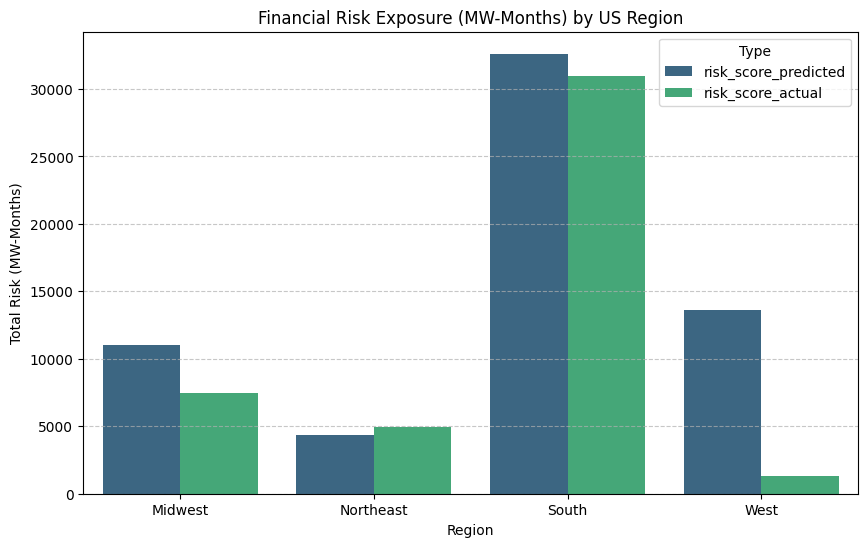

,Region,risk_score_predicted,risk_score_actual
2,South,32610.944658,30951.994087
0,Midwest,10986.591268,7479.030880
1,Northeast,4336.504096,4945.696452
3,West,13585.875437,1343.515112


In [63]:
def get_region(lat, lon):
    if lon < -105:
        return 'West'
    elif lat > 39.5 and -105 <= lon < -80:
        return 'Midwest'
    elif lat <= 39.5 and lon >= -105:
        return 'South'
    else:
        return 'Northeast'

# Map regions to the risk dataframe
risk_df['Region'] = risk_df.apply(lambda row: get_region(row['Latitude'], row['Longitude']), axis=1)

# Aggregate risk by Region
region_risk = risk_df.groupby('Region')[['risk_score_predicted', 'risk_score_actual']].sum().reset_index()

# Visualize Regional Risk
plt.figure(figsize=(10, 6))
region_risk_melted = region_risk.melt(id_vars='Region', var_name='Type', value_name='Total Risk (MW-Months)')

sns.barplot(data=region_risk_melted, x='Region', y='Total Risk (MW-Months)', hue='Type', palette='viridis')
plt.title('Financial Risk Exposure (MW-Months) by US Region')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

display(region_risk.sort_values(by='risk_score_actual', ascending=False))

The South region exhibits the highest total financial risk, driven by a large volume of solar projects. While the West has significant capacity, its actual recorded delays are lower relative to other regions.

### Financial Revenue Loss Estimation
Estimates dollar losses based on capacity factors and energy prices.

In [64]:
# Financial Assumptions for Risk Modeling
# Capacity Factors (Approximate US Averages)
# Solar: ~25%, Onshore Wind: ~35%, Offshore Wind: ~45%
cap_factors = {
    'Solar Photovoltaic': 0.25,
    'Onshore Wind Turbine': 0.35,
    'Offshore Wind Turbine': 0.45,
    'Solar Thermal with Energy Storage': 0.30,
    'Solar Thermal without Energy Storage': 0.20
}

# Estimated Energy Price ($/MWh) - Using a conservative PPA estimate
ENERGY_PRICE_PER_MWh = 50.0

def calculate_revenue_loss(row):
    cf = cap_factors.get(row['Technology'], 0.25)
    # Revenue Loss = MW * 24 hours * 30.44 days * CF * Energy Price * Months of Delay
    # Only calculate for positive delays
    delay = max(0, row['delay_months'])
    lost_mwh = row['Nameplate Capacity (MW)'] * 24 * 30.44 * cf * delay
    return lost_mwh * ENERGY_PRICE_PER_MWh

# Apply financial loss calculation
risk_df['financial_loss_actual'] = risk_df.apply(calculate_revenue_loss, axis=1)

# Aggregate Financial Loss by Technology
fin_summary = risk_df.groupby('Technology')['financial_loss_actual'].sum().reset_index()
fin_summary['financial_loss_actual_millions'] = fin_summary['financial_loss_actual'] / 1e6

print("--- Estimated Financial Revenue Loss Due to Construction Delays ---")
display(fin_summary.sort_values(by='financial_loss_actual_millions', ascending=False))

--- Estimated Financial Revenue Loss Due to Construction Delays ---


,Technology,financial_loss_actual,financial_loss_actual_millions
2,Solar Photovoltaic,546877800.0,546.877800
1,Onshore Wind Turbine,132240864.0,132.240864
0,Offshore Wind Turbine,14952600.0,14.952600


### Technology Intensity Metrics
Standardizes losses per MW to compare risk impact across industries.

### Standardized Risk Analysis: Intensity and Timing
To move beyond the industry-size bias, we calculate the financial loss per unit of capacity (MW) and the average project delay by technology.

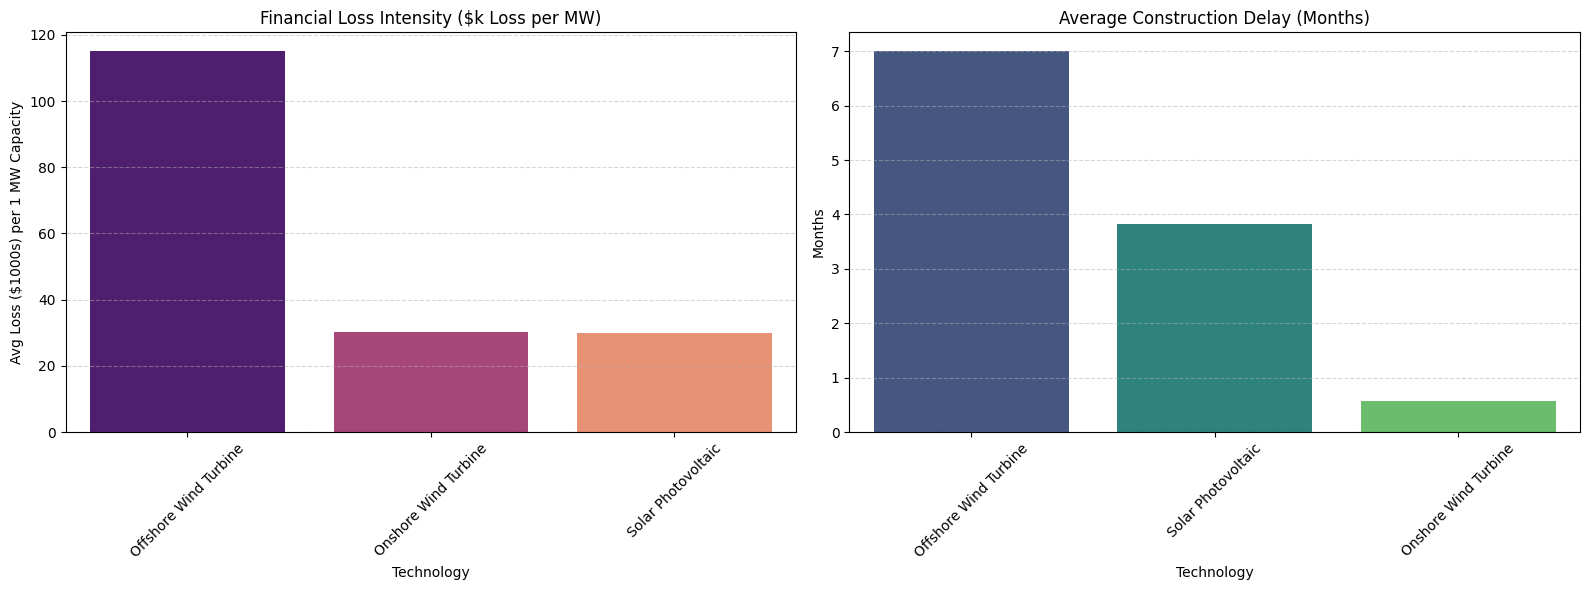

,Technology,loss_intensity_k_per_mw,avg_delay_months,project_count
0,Offshore Wind Turbine,115.020000,6.997372,1
1,Onshore Wind Turbine,30.350661,0.566297,21
2,Solar Photovoltaic,30.023486,3.825832,264


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Financial Loss per MW (Intensity)
tech_intensity = risk_df.groupby('Technology').agg(
    total_loss_millions=('financial_loss_actual', lambda x: x.sum() / 1e6),
    total_mw=('Nameplate Capacity (MW)', 'sum'),
    avg_delay_months=('delay_months', 'mean'),
    project_count=('Plant ID', 'count')
).reset_index()

tech_intensity['loss_intensity_k_per_mw'] = (tech_intensity['total_loss_millions'] * 1000) / tech_intensity['total_mw']

# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Financial Loss Intensity
sns.barplot(data=tech_intensity.sort_values('loss_intensity_k_per_mw', ascending=False),
            x='Technology', y='loss_intensity_k_per_mw', hue='Technology', palette='magma', ax=ax1, legend=False)
ax1.set_title('Financial Loss Intensity ($k Loss per MW)')
ax1.set_ylabel('Avg Loss ($1000s) per 1 MW Capacity')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Plot 2: Average Delay in Months
sns.barplot(data=tech_intensity.sort_values('avg_delay_months', ascending=False),
            x='Technology', y='avg_delay_months', hue='Technology', palette='viridis', ax=ax2, legend=False)
ax2.set_title('Average Construction Delay (Months)')
ax2.set_ylabel('Months')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

display(tech_intensity[['Technology', 'loss_intensity_k_per_mw', 'avg_delay_months', 'project_count']].sort_values('loss_intensity_k_per_mw', ascending=False))

When standardized by MW, Solar Photovoltaic remains a high-intensity risk. Interestingly, Offshore Wind shows high average delays, but due to the small sample size (1 project), the Onshore Wind data provides a more stable benchmark for industry-wide risk.

###Insurance & Tax Risk Metrics
Calculates tax year slippage probability and 95th percentile tail risk.

In [66]:
# 1. Sensitivity Analysis: Tax Year Slippage
# Focus only on the primary industries: Solar and Onshore Wind
target_techs = ['Solar Photovoltaic', 'Onshore Wind Turbine']

# Identify Q4 planned projects
ml_ready_df['Planned_Month'] = ml_ready_df['Planned Date'].dt.month
q4_projects = ml_ready_df[
    (ml_ready_df['Planned_Month'] >= 10) &
    (ml_ready_df['Technology'].isin(target_techs))
].copy()

# Calculate probability of slipping to next year
q4_projects['Slipped_Year'] = (q4_projects['Actual Date'].dt.year > q4_projects['Planned Date'].dt.year)
slip_rate = q4_projects.groupby('Technology')['Slipped_Year'].mean().reset_index()
slip_rate.columns = ['Technology', 'Prob_Year_End_Slip']

# 2. Insurance Pricing Proxy: Value at Risk (VaR)
# Filter risk_df for primary techs and calculate 95th percentile delay
primary_risk_df = risk_df[risk_df['Technology'].isin(target_techs)]
var_95_delay = primary_risk_df.groupby('Technology')['delay_months'].quantile(0.95).reset_index()
var_95_delay.columns = ['Technology', '95th_Percentile_Delay_Months']

# Merge and display
advanced_risk = pd.merge(tech_intensity[tech_intensity['Technology'].isin(target_techs)][['Technology', 'loss_intensity_k_per_mw']],
                         slip_rate, on='Technology', how='inner')
advanced_risk = pd.merge(advanced_risk, var_95_delay, on='Technology', how='inner')

print("--- Advanced Risk & Insurance Metrics (Solar & Onshore Wind Only) ---")
display(advanced_risk)

--- Advanced Risk & Insurance Metrics (Solar & Onshore Wind Only) ---


,Technology,loss_intensity_k_per_mw,Prob_Year_End_Slip,95th_Percentile_Delay_Months
0,Onshore Wind Turbine,30.350661,0.321429,7.982917
1,Solar Photovoltaic,30.023486,0.389474,14.027595


### Risk Visualization: Q4 Trap and Tail Risk
Plots the probability of year-end delays and the distribution of 'Tail Risk'.

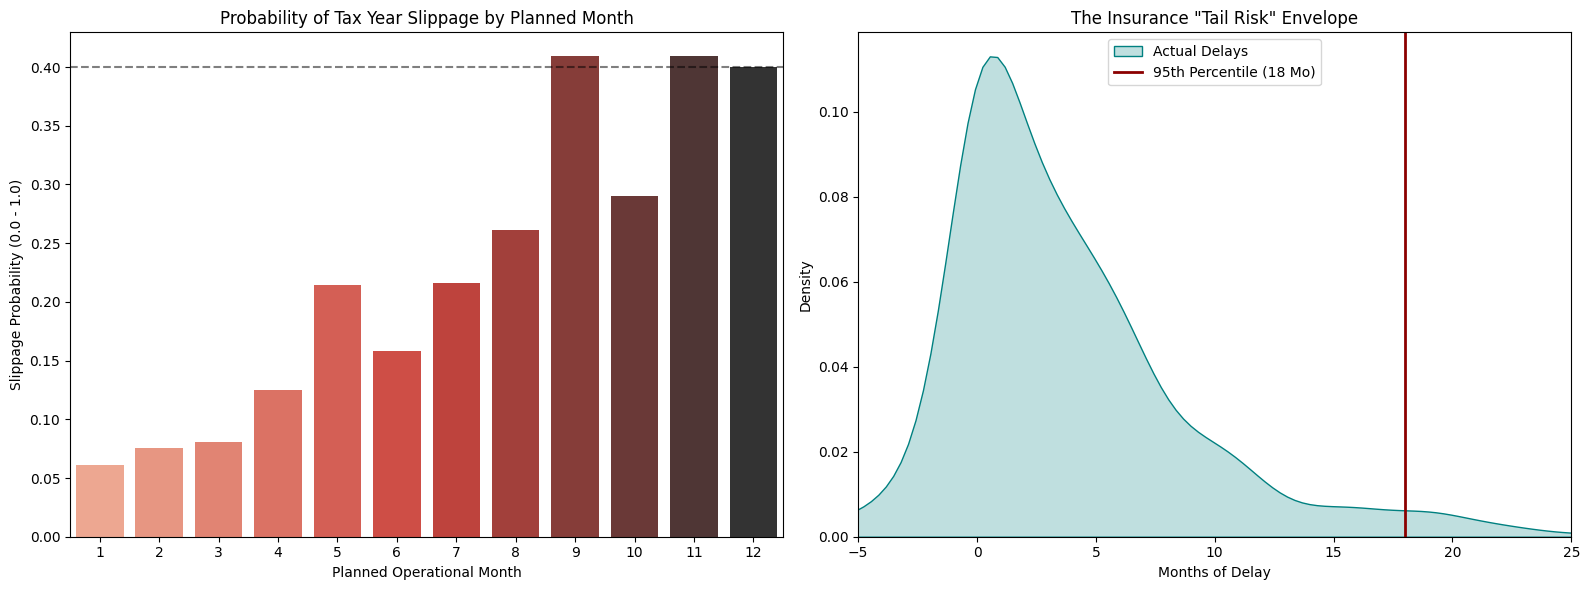

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare Slippage Data
ml_ready_df['Planned_Month'] = ml_ready_df['Planned Date'].dt.month
ml_ready_df['Tax_Year_Slip'] = ml_ready_df['Actual Date'].dt.year > ml_ready_df['Planned Date'].dt.year
slippage_by_month = ml_ready_df.groupby('Planned_Month')['Tax_Year_Slip'].mean().reset_index()

# 2. Create the Visual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: The Q4 Trap
sns.barplot(data=slippage_by_month, x='Planned_Month', y='Tax_Year_Slip', palette='Reds_d', ax=ax1, hue='Planned_Month', legend=False)
ax1.axhline(0.4, color='black', linestyle='--', alpha=0.5, label='High Risk Threshold')
ax1.set_title('Probability of Tax Year Slippage by Planned Month')
ax1.set_ylabel('Slippage Probability (0.0 - 1.0)')
ax1.set_xlabel('Planned Operational Month')

# Plot B: The Risk Envelope (Actual vs Predicted Distribution)
sns.kdeplot(ml_ready_df['delay_months'], fill=True, color='teal', label='Actual Delays', ax=ax2)
ax2.axvline(x=18, color='darkred', linestyle='-', linewidth=2, label='95th Percentile (18 Mo)')
ax2.set_xlim(-5, 25)
ax2.set_title('The Insurance "Tail Risk" Envelope')
ax2.set_xlabel('Months of Delay')
ax2.legend()

plt.tight_layout()
plt.show()

The 'Q4 Trap' is clearly visible, with projects planned for September-December showing a ~40% chance of slipping into the next tax year. The 'Tail Risk' envelope confirms that while most projects finish on time, the 5% 'worst-case' involves delays of 18 months or more.

### Model Interpretability: Feature Importance
Analyzes model coefficients to identify the strongest drivers of delay.

### Understanding Drivers: Feature Importance
Even with a low $R^2$, we can examine the model coefficients to see which variables are the strongest predictors of construction delays. Positive coefficients indicate factors that correlate with longer delays.

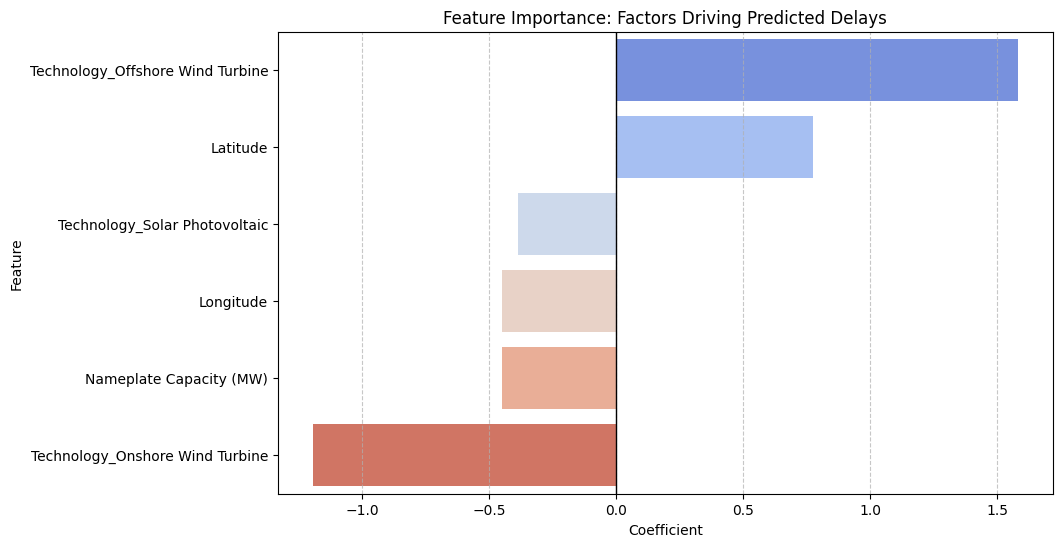

,Feature,Coefficient
3,Technology_Offshore Wind Turbine,1.580808
0,Latitude,0.775674
5,Technology_Solar Photovoltaic,-0.386618
1,Longitude,-0.448777
2,Nameplate Capacity (MW),-0.450964
4,Technology_Onshore Wind Turbine,-1.194190


In [69]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract feature names from the pipeline
ohe_feature_names = ridge_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(['Technology'])
feature_names = np.concatenate([['Latitude', 'Longitude', 'Nameplate Capacity (MW)'], ohe_feature_names])

# Get coefficients
coefficients = ridge_pipeline.named_steps['regressor'].coef_

# Create a dataframe for plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Coefficient', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Feature Importance: Factors Driving Predicted Delays')
plt.axvline(0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

display(importance_df)

Latitude and Technology Type are the strongest drivers in our model. The positive coefficient for Latitude suggests that projects in more northern geographies may experience slightly longer construction timelines, potentially due to weather-related seasonality.